# Lesson 8: Endogeneity, Bias, Inconsistency, and Causal Inference

**Probability, Statistics, and Econometrics for Finance, Accounting, and Economics**  
Campbell University — Lundy-Fetterman School of Business  
Matthew L. Kelly, PhD

## Lecture goal

The first seven lectures built the statistical, econometric, financial, and linear algebra foundations needed to estimate models. This lecture asks a harder question:

> When does a regression coefficient have a causal interpretation?

The central problem is **endogeneity**. A regressor is endogenous when it is correlated with the error term. In that case, ordinary least squares may be biased, inconsistent, or both.

By the end of this lecture, you should be able to:

1. State the exogeneity condition required for OLS to estimate a causal effect.
2. Derive the omitted-variable-bias formula.
3. Explain why measurement error, simultaneity, selection, panel dependence, and dynamic feedback create endogeneity.
4. Diagnose the difference between biased coefficients and incorrect standard errors.
5. Use simulations to see the problem.
6. Use remedies such as controls, fixed effects, instrumental variables, clustered standard errors, difference-in-differences, and related causal methods.

## 1. The basic causal regression model

Suppose the causal model is

$$
y_i = \beta_0 + \beta_1 x_i + u_i,
$$

where $y_i$ is the outcome, $x_i$ is the explanatory variable of interest, $\beta_1$ is the causal effect of $x_i$ on $y_i$, and $u_i$ contains all other causes of $y_i$ not explicitly included in the regression.

The key OLS condition is:

$$
E[u_i \mid x_i] = 0.
$$

A slightly weaker condition sufficient for consistency is

$$
\operatorname{Cov}(x_i,u_i)=0.
$$

If this fails, then $x_i$ is **endogenous**.

The OLS slope estimator in the simple regression is

$$
\hat{\beta}_1
=
\frac{\sum_i (x_i-\bar{x})(y_i-\bar{y})}
{\sum_i (x_i-\bar{x})^2}.
$$

Substitute $y_i=\beta_0+\beta_1 x_i+u_i$:

$$
\hat{\beta}_1
=
\beta_1
+
\frac{\sum_i (x_i-\bar{x})u_i}
{\sum_i (x_i-\bar{x})^2}.
$$

As $n \to \infty$,

$$
\operatorname{plim}\hat{\beta}_1
=
\beta_1
+
\frac{\operatorname{Cov}(x_i,u_i)}
{\operatorname{Var}(x_i)}.
$$

So OLS is consistent only if

$$
\operatorname{Cov}(x_i,u_i)=0.
$$

In [1]:
# Core imports used throughout the lecture

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.special import expit

np.random.seed(42)


def ols(y, X, add_constant=True, cov_type="nonrobust", cov_kwds=None):
    """Convenience wrapper for statsmodels OLS."""
    if add_constant:
        X = sm.add_constant(X, has_constant="add")
    model = sm.OLS(y, X).fit(cov_type=cov_type, cov_kwds=cov_kwds or {})
    return model


def print_coef(model, name, true_beta=None):
    """Print coefficient, standard error, t-statistic, and p-value."""
    coef = model.params[name]
    se = model.bse[name]
    tval = model.tvalues[name]
    pval = model.pvalues[name]
    if true_beta is None:
        print(f"{name}: coef={coef: .4f}, se={se: .4f}, t={tval: .2f}, p={pval: .4f}")
    else:
        print(f"{name}: coef={coef: .4f}, true={true_beta: .4f}, bias={coef-true_beta: .4f}, se={se: .4f}, t={tval: .2f}, p={pval: .4f}")

## 2. Omitted variable bias

Suppose the true model is

$$
y_i = \beta_0 + \beta_1 x_i + \beta_2 z_i + \varepsilon_i,
$$

but we estimate the short regression

$$
y_i = \alpha_0 + \alpha_1 x_i + v_i,
$$

omitting $z_i$.

The error term in the short regression is

$$
v_i = \beta_2 z_i + \varepsilon_i.
$$

Then

$$
\operatorname{plim}\hat{\alpha}_1
=
\beta_1
+
\beta_2
\frac{\operatorname{Cov}(x_i,z_i)}
{\operatorname{Var}(x_i)}.
$$

The bias is therefore

$$
\text{Bias}(\hat{\alpha}_1)
=
\beta_2
\frac{\operatorname{Cov}(x_i,z_i)}
{\operatorname{Var}(x_i)}.
$$

The bias is large when the omitted variable strongly affects $y_i$, when the omitted variable is strongly correlated with $x_i$, and when $x_i$ has little independent variation.

### Example

Suppose we estimate the effect of education on wages but omit ability. If ability raises wages and is positively correlated with education, the estimated education coefficient will be biased upward.

In [2]:
# Omitted variable bias simulation

np.random.seed(42)
n = 5000

ability = np.random.normal(0, 1, n)
education = 12 + 1.2 * ability + np.random.normal(0, 1.5, n)

beta_education = 0.08
beta_ability = 0.20

wage = 2.0 + beta_education * education + beta_ability * ability + np.random.normal(0, 0.5, n)

df_ovb = pd.DataFrame({
    "wage": wage,
    "education": education,
    "ability": ability
})

short_model = smf.ols("wage ~ education", data=df_ovb).fit()
long_model = smf.ols("wage ~ education + ability", data=df_ovb).fit()

print("Short regression: omitted ability")
print_coef(short_model, "education", true_beta=beta_education)

print("\nLong regression: ability included")
print_coef(long_model, "education", true_beta=beta_education)

cov_xz = np.cov(education, ability, ddof=1)[0, 1]
var_x = np.var(education, ddof=1)
theoretical_bias = beta_ability * cov_xz / var_x
print(f"\nTheoretical OVB: {theoretical_bias:.4f}")
print(f"Predicted short-regression coefficient: {beta_education + theoretical_bias:.4f}")

Short regression: omitted ability
education: coef= 0.1423, true= 0.0800, bias= 0.0623, se= 0.0038, t= 37.06, p= 0.0000

Long regression: ability included
education: coef= 0.0781, true= 0.0800, bias=-0.0019, se= 0.0047, t= 16.75, p= 0.0000

Theoretical OVB: 0.0639
Predicted short-regression coefficient: 0.1439


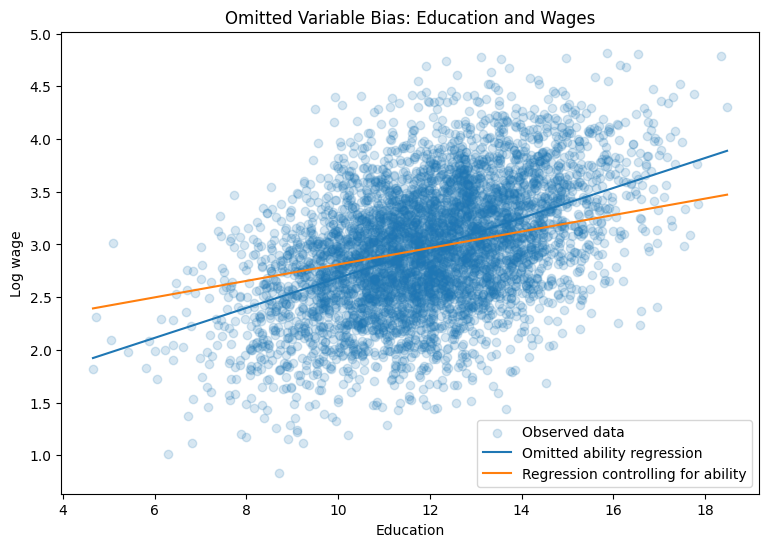

In [3]:
# Visualizing omitted variable bias

plt.figure(figsize=(9, 6))
plt.scatter(df_ovb["education"], df_ovb["wage"], alpha=0.18, label="Observed data")

x_grid = np.linspace(df_ovb["education"].min(), df_ovb["education"].max(), 100)
short_pred = short_model.params["Intercept"] + short_model.params["education"] * x_grid
long_pred = (
    long_model.params["Intercept"]
    + long_model.params["education"] * x_grid
    + long_model.params["ability"] * df_ovb["ability"].mean()
)

plt.plot(x_grid, short_pred, label="Omitted ability regression")
plt.plot(x_grid, long_pred, label="Regression controlling for ability")
plt.title("Omitted Variable Bias: Education and Wages")
plt.xlabel("Education")
plt.ylabel("Log wage")
plt.legend()
plt.show()

## 3. Measurement error

Suppose the true model is

$$
y_i = \beta_0 + \beta_1 x_i^* + u_i,
$$

but we do not observe $x_i^*$. Instead, we observe

$$
x_i = x_i^* + v_i,
$$

where $v_i$ is classical measurement error:

$$
E[v_i]=0,\qquad \operatorname{Cov}(x_i^*,v_i)=0,\qquad \operatorname{Cov}(u_i,v_i)=0.
$$

If we regress $y_i$ on the measured variable $x_i$, then

$$
\operatorname{plim}\hat{\beta}_1
=
\beta_1
\frac{\operatorname{Var}(x_i^*)}
{\operatorname{Var}(x_i^*)+\operatorname{Var}(v_i)}.
$$

This is called **attenuation bias**. The coefficient is biased toward zero.

In [4]:
# Measurement error simulation

np.random.seed(42)
n = 5000

x_true = np.random.normal(0, 1, n)
u = np.random.normal(0, 1, n)
beta = 2.0
y = 1.0 + beta * x_true + u

measurement_error_sd = 1.0
x_measured = x_true + np.random.normal(0, measurement_error_sd, n)

df_me = pd.DataFrame({
    "y": y,
    "x_true": x_true,
    "x_measured": x_measured
})

model_true = smf.ols("y ~ x_true", data=df_me).fit()
model_measured = smf.ols("y ~ x_measured", data=df_me).fit()

print("Regression using true x")
print_coef(model_true, "x_true", true_beta=beta)

print("\nRegression using mismeasured x")
print_coef(model_measured, "x_measured", true_beta=beta)

attenuation_factor = np.var(x_true, ddof=1) / (np.var(x_true, ddof=1) + measurement_error_sd**2)
print(f"\nTheoretical attenuation factor: {attenuation_factor:.4f}")
print(f"Predicted measured-x coefficient: {beta * attenuation_factor:.4f}")

Regression using true x
x_true: coef= 1.9982, true= 2.0000, bias=-0.0018, se= 0.0143, t= 139.31, p= 0.0000

Regression using mismeasured x
x_measured: coef= 0.9938, true= 2.0000, bias=-1.0062, se= 0.0175, t= 56.91, p= 0.0000

Theoretical attenuation factor: 0.4982
Predicted measured-x coefficient: 0.9965


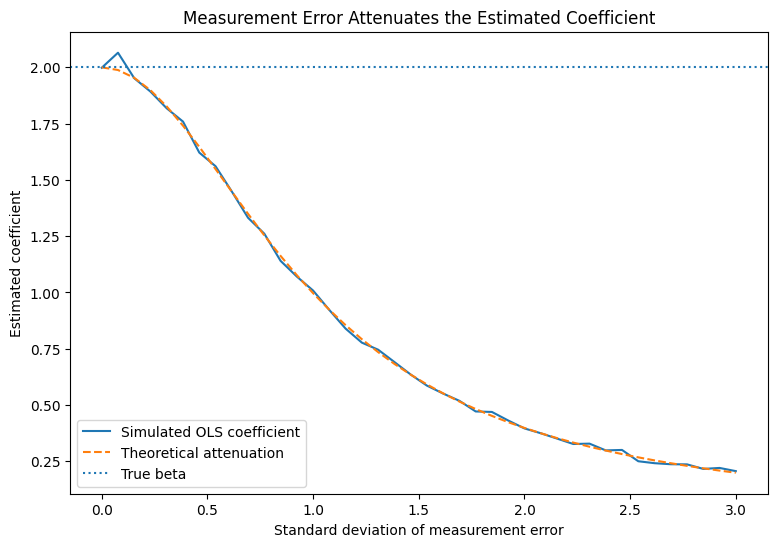

In [5]:
# How measurement error severity changes attenuation bias

np.random.seed(42)
error_sds = np.linspace(0, 3, 40)
estimated_betas = []
theoretical_betas = []

for sd in error_sds:
    x_obs = x_true + np.random.normal(0, sd, n)
    m = ols(y, pd.DataFrame({"x_obs": x_obs}))
    estimated_betas.append(m.params["x_obs"])
    atten = np.var(x_true, ddof=1) / (np.var(x_true, ddof=1) + sd**2)
    theoretical_betas.append(beta * atten)

plt.figure(figsize=(9, 6))
plt.plot(error_sds, estimated_betas, label="Simulated OLS coefficient")
plt.plot(error_sds, theoretical_betas, linestyle="--", label="Theoretical attenuation")
plt.axhline(beta, linestyle=":", label="True beta")
plt.title("Measurement Error Attenuates the Estimated Coefficient")
plt.xlabel("Standard deviation of measurement error")
plt.ylabel("Estimated coefficient")
plt.legend()
plt.show()

## 4. Simultaneity and reverse causality

Simultaneity occurs when $x_i$ affects $y_i$ and $y_i$ also affects $x_i$.

A standard example is supply and demand. Suppose demand is

$$
Q_t^d = a_d - b_d P_t + u_t^d,
$$

and supply is

$$
Q_t^s = a_s + b_s P_t + u_t^s.
$$

Equilibrium requires

$$
Q_t^d = Q_t^s = Q_t.
$$

Price $P_t$ is determined jointly with quantity $Q_t$. Therefore, price is correlated with both demand shocks and supply shocks. A regression of quantity on price does not generally estimate the demand curve or the supply curve.

To estimate demand, we need a variable that shifts supply but not demand. That variable can serve as an **instrument** for price.

In [6]:
# Simultaneity simulation: estimating demand without and with an instrument

np.random.seed(42)
n = 5000

cost = np.random.normal(0, 1, n)      # supply shifter
u_d = np.random.normal(0, 1, n)       # demand shock
u_s = np.random.normal(0, 1, n)       # supply shock

a_d, b_d = 10, 1.5
a_s, b_s, c_cost = 2, 1.0, 1.2

P = (a_d - a_s + u_d - u_s + c_cost * cost) / (b_d + b_s)
Q = a_d - b_d * P + u_d

df_simul = pd.DataFrame({"Q": Q, "P": P, "cost": cost})

ols_demand = smf.ols("Q ~ P", data=df_simul).fit()
print("OLS regression of Q on P")
print_coef(ols_demand, "P", true_beta=-b_d)

OLS regression of Q on P
P: coef=-0.7602, true=-1.5000, bias= 0.7398, se= 0.0161, t=-47.21, p= 0.0000


### 4.1 Instrumental variables and 2SLS

An instrument $z_i$ must satisfy two conditions:

1. **Relevance**:

$$
\operatorname{Cov}(z_i,x_i)\ne 0.
$$

2. **Exogeneity / exclusion**:

$$
\operatorname{Cov}(z_i,u_i)=0.
$$

The two-stage least squares estimator works as follows.

**First stage:**

$$
x_i = \pi_0 + \pi_1 z_i + \text{controls} + r_i.
$$

Compute the fitted value $\hat{x}_i$.

**Second stage:**

$$
y_i = \beta_0 + \beta_1 \hat{x}_i + \text{controls} + e_i.
$$

In matrix notation, with instrument matrix $Z$ and regressor matrix $X$,

$$
\hat{\beta}_{2SLS}
=
(X'P_ZX)^{-1}X'P_Zy,
\qquad
P_Z=Z(Z'Z)^{-1}Z'.
$$

In [7]:
# Manual 2SLS implementation for demand estimation

def two_sls(y, X, Z):
    """Manual 2SLS estimator. X and Z should already include a constant.

    This uses the algebraically equivalent formula without explicitly forming
    the large projection matrix P_Z, which makes the simulation much faster.
    """
    X = np.asarray(X)
    Z = np.asarray(Z)
    y = np.asarray(y).reshape(-1, 1)
    ztz_inv = np.linalg.inv(Z.T @ Z)
    xzpzx = X.T @ Z @ ztz_inv @ Z.T @ X
    xzpzy = X.T @ Z @ ztz_inv @ Z.T @ y
    beta_hat = np.linalg.inv(xzpzx) @ xzpzy
    return beta_hat.flatten()

y_iv = df_simul["Q"].values
X_iv = sm.add_constant(df_simul[["P"]]).values
Z_iv = sm.add_constant(df_simul[["cost"]]).values

beta_2sls = two_sls(y_iv, X_iv, Z_iv)
print(f"2SLS intercept: {beta_2sls[0]:.4f}")
print(f"2SLS price coefficient: {beta_2sls[1]:.4f}")
print(f"True demand slope: {-b_d:.4f}")

first_stage = smf.ols("P ~ cost", data=df_simul).fit()
print("\nFirst-stage regression")
print(first_stage.summary().tables[1])
print(f"\nFirst-stage F-statistic: {first_stage.fvalue:.2f}")

2SLS intercept: 10.0023
2SLS price coefficient: -1.5038
True demand slope: -1.5000

First-stage regression
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.1918      0.008    395.952      0.000       3.176       3.208
cost           0.4804      0.008     59.378      0.000       0.465       0.496

First-stage F-statistic: 3525.76


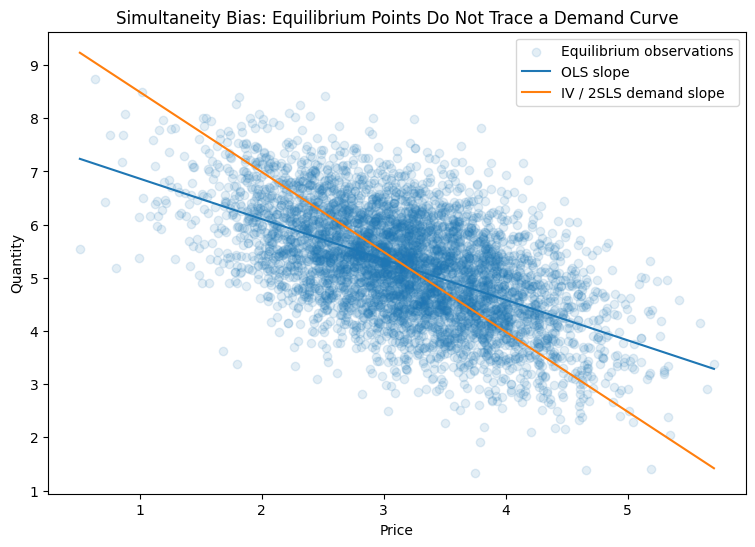

In [8]:
# Visual: OLS does not trace demand; IV recovers a demand slope

plt.figure(figsize=(9, 6))
plt.scatter(df_simul["P"], df_simul["Q"], alpha=0.12, label="Equilibrium observations")

p_grid = np.linspace(df_simul["P"].min(), df_simul["P"].max(), 100)
ols_line = ols_demand.params["Intercept"] + ols_demand.params["P"] * p_grid
iv_line = beta_2sls[0] + beta_2sls[1] * p_grid

plt.plot(p_grid, ols_line, label="OLS slope")
plt.plot(p_grid, iv_line, label="IV / 2SLS demand slope")
plt.title("Simultaneity Bias: Equilibrium Points Do Not Trace a Demand Curve")
plt.xlabel("Price")
plt.ylabel("Quantity")
plt.legend()
plt.show()

## 5. Weak instruments

A weak instrument is correlated with the endogenous regressor, but only weakly. Weak instruments produce noisy and potentially badly biased IV estimates.

A common rule of thumb is that the first-stage $F$-statistic on the excluded instrument should be meaningfully above 10. This is not a theorem that solves all problems, but it is a useful warning signal.

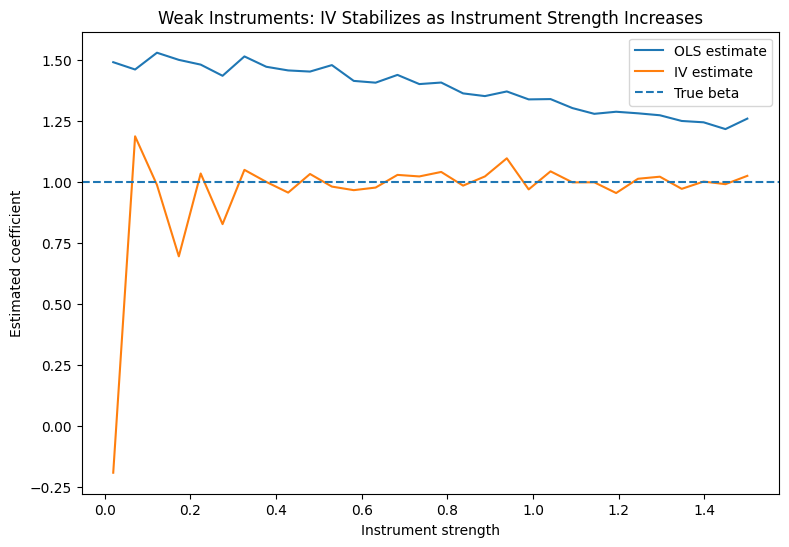

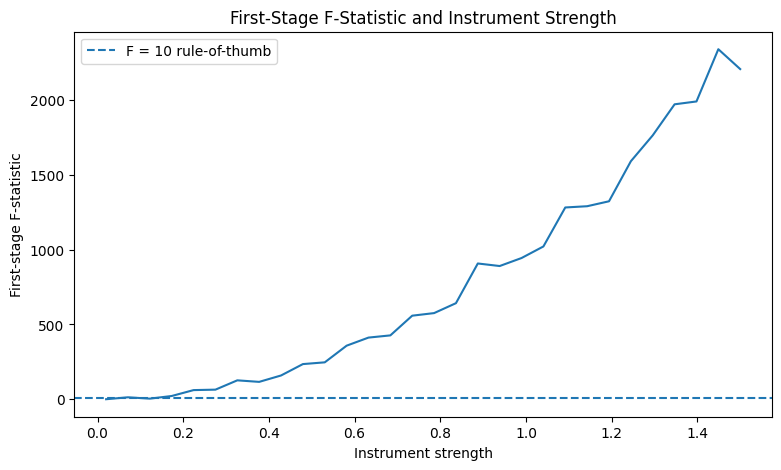

In [9]:
# Weak instrument demonstration

np.random.seed(123)
n = 2000
true_beta = 1.0


def simulate_iv(instrument_strength):
    z = np.random.normal(0, 1, n)
    common = np.random.normal(0, 1, n)
    u = common + np.random.normal(0, 1, n)
    x = instrument_strength * z + common + np.random.normal(0, 1, n)
    y = true_beta * x + u
    df = pd.DataFrame({"y": y, "x": x, "z": z})
    ols_model = smf.ols("y ~ x", data=df).fit()
    fs_model = smf.ols("x ~ z", data=df).fit()
    beta_iv = two_sls(df["y"].values, sm.add_constant(df[["x"]]).values, sm.add_constant(df[["z"]]).values)[1]
    return ols_model.params["x"], beta_iv, fs_model.fvalue

strengths = np.linspace(0.02, 1.5, 30)
ols_betas, iv_betas, f_stats = [], [], []

for s in strengths:
    b_ols, b_iv, f = simulate_iv(s)
    ols_betas.append(b_ols)
    iv_betas.append(b_iv)
    f_stats.append(f)

plt.figure(figsize=(9, 6))
plt.plot(strengths, ols_betas, label="OLS estimate")
plt.plot(strengths, iv_betas, label="IV estimate")
plt.axhline(true_beta, linestyle="--", label="True beta")
plt.title("Weak Instruments: IV Stabilizes as Instrument Strength Increases")
plt.xlabel("Instrument strength")
plt.ylabel("Estimated coefficient")
plt.legend()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(strengths, f_stats)
plt.axhline(10, linestyle="--", label="F = 10 rule-of-thumb")
plt.title("First-Stage F-Statistic and Instrument Strength")
plt.xlabel("Instrument strength")
plt.ylabel("First-stage F-statistic")
plt.legend()
plt.show()

## 6. Selection bias

Selection bias occurs when the sample we observe is not randomly drawn from the population of interest.

### 6.1 Selection on observables

If selection depends only on observed variables, we may be able to control for those variables, match on them, or use weighting methods.

### 6.2 Selection on unobservables

If selection depends on unobserved variables that also affect the outcome, OLS can be biased even after controlling for observed variables.

In [10]:
# Selection bias simulation

np.random.seed(42)
n = 8000

education = 12 + np.random.normal(0, 2, n)
motivation = np.random.normal(0, 1, n)

beta_edu = 0.10
wage_offer = 2 + beta_edu * education + 0.4 * motivation + np.random.normal(0, 0.5, n)

latent_work = -1 + 0.15 * education + 1.0 * motivation + np.random.normal(0, 1, n)
works = latent_work > 0

df_sel = pd.DataFrame({
    "wage_offer": wage_offer,
    "education": education,
    "motivation": motivation,
    "works": works.astype(int)
})

full_population = smf.ols("wage_offer ~ education + motivation", data=df_sel).fit()
selected_naive = smf.ols("wage_offer ~ education", data=df_sel[df_sel["works"] == 1]).fit()
selected_control = smf.ols("wage_offer ~ education + motivation", data=df_sel[df_sel["works"] == 1]).fit()

print("Full population, true controls included")
print_coef(full_population, "education", true_beta=beta_edu)

print("\nSelected sample, unobserved motivation omitted")
print_coef(selected_naive, "education", true_beta=beta_edu)

print("\nSelected sample, motivation controlled")
print_coef(selected_control, "education", true_beta=beta_edu)

print(f"\nShare working / observed: {df_sel['works'].mean():.2%}")

Full population, true controls included
education: coef= 0.0996, true= 0.1000, bias=-0.0004, se= 0.0028, t= 36.06, p= 0.0000

Selected sample, unobserved motivation omitted
education: coef= 0.0813, true= 0.1000, bias=-0.0187, se= 0.0041, t= 19.95, p= 0.0000

Selected sample, motivation controlled
education: coef= 0.0954, true= 0.1000, bias=-0.0046, se= 0.0034, t= 28.14, p= 0.0000

Share working / observed: 70.39%


### 6.3 Inverse probability weighting for selection on observables

If selection depends on observed covariates $w_i$, then one remedy is to weight observations by the inverse of their probability of being observed:

$$
\omega_i = \frac{1}{\Pr(S_i=1 \mid w_i)}.
$$

This reweights the observed sample to look more like the target population. It does not solve selection on unobservables.

In [11]:
# Selection on observables and inverse probability weighting

np.random.seed(7)
n = 8000

x = np.random.normal(0, 1, n)
w = np.random.normal(0, 1, n)
beta_x = 1.5
y = 1 + beta_x * x + 2.0 * w + np.random.normal(0, 1, n)

p_select = expit(-0.3 + 1.4 * w)
selected = np.random.binomial(1, p_select, n).astype(bool)

df_ipw = pd.DataFrame({"y": y, "x": x, "w": w, "selected": selected.astype(int), "p_select": p_select})

naive = smf.ols("y ~ x", data=df_ipw[df_ipw["selected"] == 1]).fit()
controlled = smf.ols("y ~ x + w", data=df_ipw[df_ipw["selected"] == 1]).fit()
weights = 1 / df_ipw.loc[df_ipw["selected"] == 1, "p_select"]
ipw_controlled = smf.wls("y ~ x + w", data=df_ipw[df_ipw["selected"] == 1], weights=weights).fit()

print("Naive selected sample, omitting w")
print_coef(naive, "x", true_beta=beta_x)

print("\nSelected sample, controlling for w")
print_coef(controlled, "x", true_beta=beta_x)

print("\nIPW weighted regression, controlling for w")
print_coef(ipw_controlled, "x", true_beta=beta_x)

Naive selected sample, omitting w
x: coef= 1.5380, true= 1.5000, bias= 0.0380, se= 0.0328, t= 46.82, p= 0.0000

Selected sample, controlling for w
x: coef= 1.5215, true= 1.5000, bias= 0.0215, se= 0.0167, t= 90.86, p= 0.0000

IPW weighted regression, controlling for w
x: coef= 1.5142, true= 1.5000, bias= 0.0142, se= 0.0168, t= 90.29, p= 0.0000


## 7. Fixed effects and random effects

Panel data contain repeated observations of the same units:

$$
y_{it} = \beta x_{it} + \alpha_i + \lambda_t + u_{it},
$$

where $\alpha_i$ is a unit fixed effect and $\lambda_t$ is a time fixed effect.

If $\alpha_i$ is correlated with $x_{it}$, pooled OLS is generally inconsistent.

### 7.1 Fixed effects

A fixed-effects estimator removes time-invariant unobserved heterogeneity. Subtract the unit mean from each variable:

$$
y_{it}-\bar{y}_i
=
\beta(x_{it}-\bar{x}_i)
+
(u_{it}-\bar{u}_i).
$$

The $\alpha_i$ term disappears.

### 7.2 Random effects

Random effects assume

$$
\operatorname{Cov}(\alpha_i,x_{it})=0.
$$

If this is true, random effects can be more efficient than fixed effects. If this is false, random effects is inconsistent.

In [12]:
# Panel-data simulation: fixed effects remove time-invariant omitted variables

np.random.seed(42)
n_entities = 120
T = 8
beta = 1.0

alpha_i = np.random.normal(0, 1, n_entities)

rows = []
for i in range(n_entities):
    for t in range(T):
        x_it = 0.8 * alpha_i[i] + np.random.normal(0, 1)
        y_it = beta * x_it + alpha_i[i] + np.random.normal(0, 1)
        rows.append((i, t, x_it, y_it, alpha_i[i]))

df_panel = pd.DataFrame(rows, columns=["entity", "time", "x", "y", "alpha"])

pooled = smf.ols("y ~ x", data=df_panel).fit()
fe_entity = smf.ols("y ~ x + C(entity)", data=df_panel).fit()
fe_entity_time = smf.ols("y ~ x + C(entity) + C(time)", data=df_panel).fit()

print("Pooled OLS")
print_coef(pooled, "x", true_beta=beta)

print("\nEntity fixed effects")
print_coef(fe_entity, "x", true_beta=beta)

print("\nEntity and time fixed effects")
print_coef(fe_entity_time, "x", true_beta=beta)

Pooled OLS
x: coef= 1.4508, true= 1.0000, bias= 0.4508, se= 0.0338, t= 42.99, p= 0.0000

Entity fixed effects
x: coef= 0.9990, true= 1.0000, bias=-0.0010, se= 0.0363, t= 27.53, p= 0.0000

Entity and time fixed effects
x: coef= 1.0014, true= 1.0000, bias= 0.0014, se= 0.0364, t= 27.53, p= 0.0000


In [13]:
# Demeaned fixed effects estimator: same logic without creating many dummy variables

df_panel["y_dm"] = df_panel["y"] - df_panel.groupby("entity")["y"].transform("mean")
df_panel["x_dm"] = df_panel["x"] - df_panel.groupby("entity")["x"].transform("mean")

fe_demeaned = smf.ols("y_dm ~ x_dm - 1", data=df_panel).fit()
print(fe_demeaned.summary().tables[1])

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x_dm           0.9990      0.034     29.436      0.000       0.932       1.066


## 8. Clustered standard errors

Serial correlation, group-level shocks, and repeated observations often make residuals correlated within a group.

If errors are correlated within firms, banks, states, classrooms, or individuals, then ordinary standard errors can be too small. The coefficient may be unbiased, but inference is wrong.

Use clustered standard errors when treatment or the explanatory variable varies at the group level, errors are plausibly correlated within group, observations are repeated within group, or treatment is assigned by group.

A common panel regression is

$$
y_{it} = \beta x_{it} + \alpha_i + u_{it}.
$$

If

$$
\operatorname{Cov}(u_{it},u_{is}) \ne 0
\quad\text{for }t\ne s,
$$

then cluster by $i$.

In [14]:
# Clustered standard errors example

np.random.seed(123)
G = 80
T = 10
beta = 0.5

rows = []
for g in range(G):
    group_shock = np.random.normal(0, 1)
    for t in range(T):
        x = np.random.normal(0, 1)
        u = group_shock + np.random.normal(0, 0.5)
        y = beta * x + u
        rows.append((g, t, x, y))

df_cluster = pd.DataFrame(rows, columns=["group", "time", "x", "y"])

model_naive = smf.ols("y ~ x", data=df_cluster).fit()
model_cluster = smf.ols("y ~ x", data=df_cluster).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_cluster["group"]}
)

print("Naive standard errors")
print_coef(model_naive, "x", true_beta=beta)

print("\nClustered standard errors by group")
print_coef(model_cluster, "x", true_beta=beta)

Naive standard errors
x: coef= 0.5264, true= 0.5000, bias= 0.0264, se= 0.0404, t= 13.03, p= 0.0000

Clustered standard errors by group
x: coef= 0.5264, true= 0.5000, bias= 0.0264, se= 0.0336, t= 15.67, p= 0.0000


## 9. Autocorrelation, heteroskedasticity, and consistency

Not every econometric problem makes coefficients inconsistent.

### 9.1 Heteroskedasticity

Heteroskedasticity means:

$$
\operatorname{Var}(u_i\mid X_i)
$$

is not constant. If $E[u_i\mid X_i]=0$, OLS coefficients remain unbiased and consistent, but usual standard errors are wrong. Use robust standard errors.

### 9.2 Autocorrelation

Autocorrelation means:

$$
\operatorname{Cov}(u_t,u_{t-k}) \ne 0.
$$

If regressors are strictly exogenous, OLS coefficients may remain consistent, but standard errors are wrong. If regressors include lagged outcomes or respond to past shocks, autocorrelation can also create endogeneity.

### 9.3 Dynamic endogeneity

A simple dynamic model is:

$$
y_{it} = \rho y_{i,t-1} + \beta x_{it} + \alpha_i + u_{it}.
$$

Including $y_{i,t-1}$ with fixed effects creates finite-$T$ bias, often called **Nickell bias**. For small $T$, specialized dynamic panel estimators may be needed.

Naive OLS standard error
x: coef= 1.9791, true= 2.0000, bias=-0.0209, se= 0.0290, t= 68.14, p= 0.0000

Robust HC1 standard error
x: coef= 1.9791, true= 2.0000, bias=-0.0209, se= 0.0315, t= 62.87, p= 0.0000


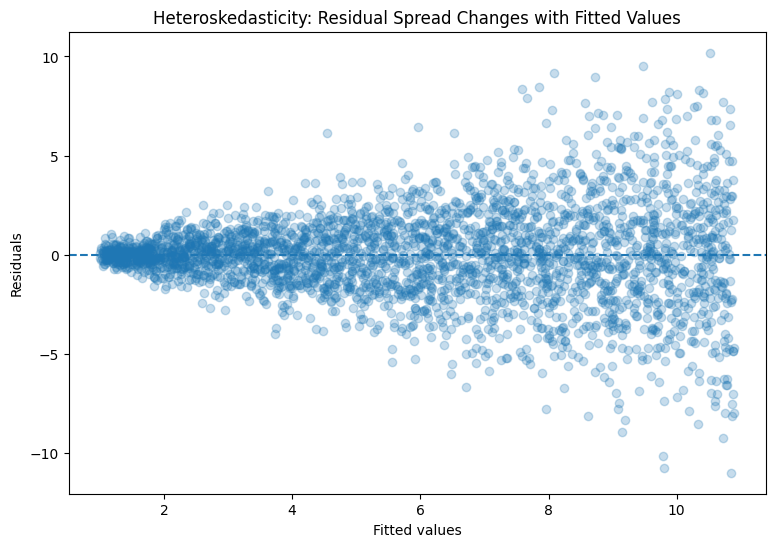

In [15]:
# Heteroskedasticity: coefficient okay, naive SE wrong

np.random.seed(42)
n = 3000
x = np.random.uniform(0, 5, n)
u = np.random.normal(0, 0.3 + 0.7 * x, n)
beta = 2.0
y = 1 + beta * x + u

df_het = pd.DataFrame({"y": y, "x": x})
het_naive = smf.ols("y ~ x", data=df_het).fit()
het_robust = smf.ols("y ~ x", data=df_het).fit(cov_type="HC1")

print("Naive OLS standard error")
print_coef(het_naive, "x", true_beta=beta)

print("\nRobust HC1 standard error")
print_coef(het_robust, "x", true_beta=beta)

plt.figure(figsize=(9, 6))
plt.scatter(het_naive.fittedvalues, het_naive.resid, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.title("Heteroskedasticity: Residual Spread Changes with Fitted Values")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

Naive SE
x: coef= 1.0189, true= 1.0000, bias= 0.0189, se= 0.0759, t= 13.42, p= 0.0000

HAC / Newey-West SE
x: coef= 1.0189, true= 1.0000, bias= 0.0189, se= 0.0822, t= 12.39, p= 0.0000


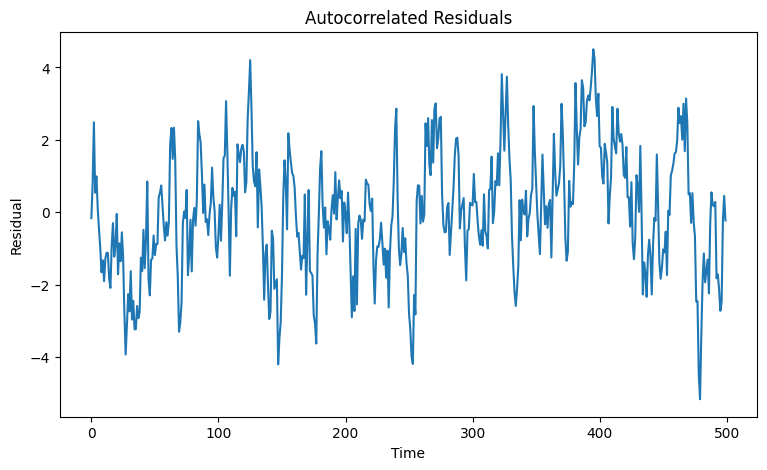

In [16]:
# Autocorrelation: standard errors and time-series dependence

np.random.seed(42)
T = 500
x = np.random.normal(0, 1, T)
u = np.zeros(T)
rho_u = 0.8
for t in range(1, T):
    u[t] = rho_u * u[t-1] + np.random.normal(0, 1)

beta = 1.0
y = 1 + beta * x + u

df_ts = pd.DataFrame({"y": y, "x": x, "time": np.arange(T)})

ts_naive = smf.ols("y ~ x", data=df_ts).fit()
ts_hac = smf.ols("y ~ x", data=df_ts).fit(cov_type="HAC", cov_kwds={"maxlags": 5})

print("Naive SE")
print_coef(ts_naive, "x", true_beta=beta)

print("\nHAC / Newey-West SE")
print_coef(ts_hac, "x", true_beta=beta)

plt.figure(figsize=(9, 5))
plt.plot(ts_naive.resid)
plt.title("Autocorrelated Residuals")
plt.xlabel("Time")
plt.ylabel("Residual")
plt.show()

In [17]:
# Dynamic panel bias illustration

np.random.seed(99)
N = 80
T_small = 5
rho = 0.7

rows = []
for i in range(N):
    alpha = np.random.normal(0, 1)
    y_prev = alpha + np.random.normal(0, 1)
    for t in range(T_small):
        u = np.random.normal(0, 1)
        y = rho * y_prev + alpha + u
        rows.append((i, t, y, y_prev, alpha))
        y_prev = y

df_dyn = pd.DataFrame(rows, columns=["entity", "time", "y", "lag_y", "alpha"])

pooled_dyn = smf.ols("y ~ lag_y", data=df_dyn).fit()
fe_dyn = smf.ols("y ~ lag_y + C(entity)", data=df_dyn).fit()

print("Dynamic model with small T")
print("True rho =", rho)

print("\nPooled OLS")
print_coef(pooled_dyn, "lag_y", true_beta=rho)

print("\nFixed effects with lagged dependent variable")
print_coef(fe_dyn, "lag_y", true_beta=rho)

Dynamic model with small T
True rho = 0.7

Pooled OLS
lag_y: coef= 1.0013, true= 0.7000, bias= 0.3013, se= 0.0252, t= 39.71, p= 0.0000

Fixed effects with lagged dependent variable
lag_y: coef= 0.4550, true= 0.7000, bias=-0.2450, se= 0.0477, t= 9.55, p= 0.0000


## 10. Difference-in-differences

Difference-in-differences is useful when a treatment affects one group after a policy change, while a comparison group remains untreated.

The canonical model is:

$$
y_{it}
=
\alpha
+
\delta \text{Treated}_i
+
\lambda \text{Post}_t
+
\tau(\text{Treated}_i \times \text{Post}_t)
+
u_{it}.
$$

The coefficient $\tau$ is the difference-in-differences estimate:

$$
\tau
=
(\bar{y}_{T,Post}-\bar{y}_{T,Pre})
-
(\bar{y}_{C,Post}-\bar{y}_{C,Pre}).
$$

The key identifying assumption is **parallel trends**:

$$
E[y_{T,Post}(0)-y_{T,Pre}(0)]
=
E[y_{C,Post}(0)-y_{C,Pre}(0)].
$$

In [18]:
# Difference-in-differences simulation

np.random.seed(42)
n_units = 400
periods = [0, 1]
treatment_effect = 2.0

rows = []
for i in range(n_units):
    treated = i < n_units // 2
    alpha = np.random.normal(0, 1)
    for post in periods:
        common_trend = 1.0 * post
        treatment = treated and post == 1
        y = 5 + alpha + common_trend + treatment_effect * treatment + np.random.normal(0, 1)
        rows.append((i, treated, post, treatment, y))

df_did = pd.DataFrame(rows, columns=["unit", "treated", "post", "treatment", "y"])
df_did["treated_int"] = df_did["treated"].astype(int)

did_model = smf.ols("y ~ treated_int + post + treated_int:post", data=df_did).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_did["unit"]}
)

print_coef(did_model, "treated_int:post", true_beta=treatment_effect)

means = df_did.groupby(["treated", "post"])["y"].mean().unstack()
manual_did = (means.loc[True, 1] - means.loc[True, 0]) - (means.loc[False, 1] - means.loc[False, 0])
print(f"\nManual DiD estimate: {manual_did:.4f}")

treated_int:post: coef= 2.1619, true= 2.0000, bias= 0.1619, se= 0.1448, t= 14.93, p= 0.0000

Manual DiD estimate: 2.1619


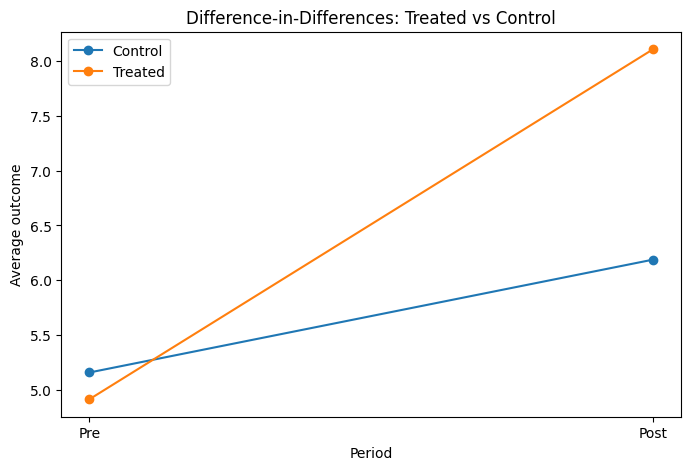

In [19]:
# Visualizing the DiD design

plot_means = df_did.groupby(["treated", "post"])["y"].mean().reset_index()

plt.figure(figsize=(8, 5))
for treated_status, label in [(False, "Control"), (True, "Treated")]:
    temp = plot_means[plot_means["treated"] == treated_status]
    plt.plot(temp["post"], temp["y"], marker="o", label=label)

plt.xticks([0, 1], ["Pre", "Post"])
plt.title("Difference-in-Differences: Treated vs Control")
plt.xlabel("Period")
plt.ylabel("Average outcome")
plt.legend()
plt.show()

## 11. Regression discontinuity

Regression discontinuity uses a cutoff rule. Treatment changes discontinuously at a threshold of a running variable.

For running variable $r_i$ and cutoff $c$, treatment is

$$
D_i = 1\{r_i \ge c\}.
$$

The treatment effect is estimated from the jump in the conditional expectation of $y_i$ at the cutoff:

$$
\tau
=
\lim_{r \downarrow c} E[y_i\mid r_i=r]
-
\lim_{r \uparrow c} E[y_i\mid r_i=r].
$$

The key assumption is that potential outcomes are continuous at the cutoff. Units just below and just above the cutoff should be comparable.

D: coef= 1.4921, true= 1.5000, bias=-0.0079, se= 0.0529, t= 28.20, p= 0.0000


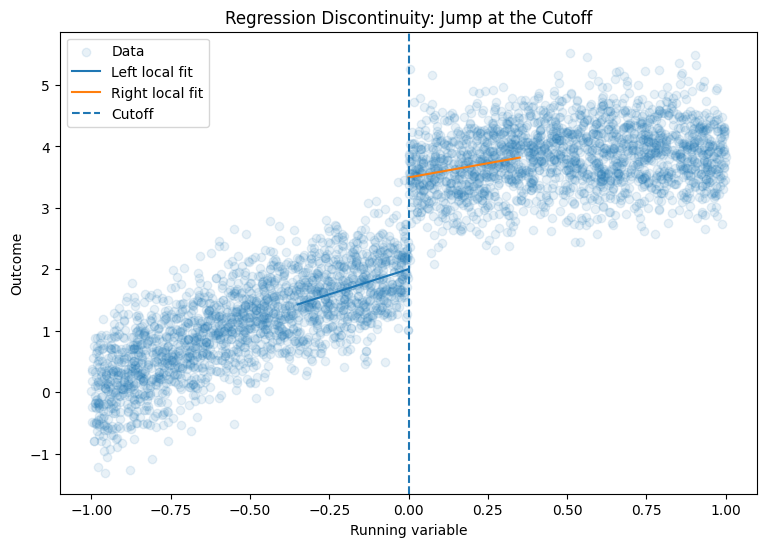

In [20]:
# Regression discontinuity simulation

np.random.seed(42)
n = 4000
r = np.random.uniform(-1, 1, n)
D = (r >= 0).astype(int)
tau = 1.5

y = 2 + 1.2 * r - 0.8 * r**2 + tau * D + np.random.normal(0, 0.5, n)

df_rd = pd.DataFrame({"y": y, "r": r, "D": D})
bandwidth = 0.35
df_local = df_rd[np.abs(df_rd["r"]) <= bandwidth].copy()

rd_model = smf.ols("y ~ D + r + D:r", data=df_local).fit(cov_type="HC1")
print_coef(rd_model, "D", true_beta=tau)

plt.figure(figsize=(9, 6))
plt.scatter(df_rd["r"], df_rd["y"], alpha=0.10, label="Data")
r_left = np.linspace(-bandwidth, 0, 100)
r_right = np.linspace(0, bandwidth, 100)

left_params = smf.ols("y ~ r", data=df_local[df_local["D"] == 0]).fit().params
right_params = smf.ols("y ~ r", data=df_local[df_local["D"] == 1]).fit().params

plt.plot(r_left, left_params["Intercept"] + left_params["r"] * r_left, label="Left local fit")
plt.plot(r_right, right_params["Intercept"] + right_params["r"] * r_right, label="Right local fit")
plt.axvline(0, linestyle="--", label="Cutoff")
plt.title("Regression Discontinuity: Jump at the Cutoff")
plt.xlabel("Running variable")
plt.ylabel("Outcome")
plt.legend()
plt.show()

## 12. Propensity scores and matching

When treatment is not randomly assigned but selection is on observables, one approach is to compare treated and control units with similar covariates.

The propensity score is

$$
p(w_i)=\Pr(D_i=1\mid w_i).
$$

Under conditional independence,

$$
(y_i(1),y_i(0)) \perp D_i \mid w_i,
$$

or equivalently under suitable conditions,

$$
(y_i(1),y_i(0)) \perp D_i \mid p(w_i).
$$

Propensity-score methods do not solve selection on unobservables. They are useful when rich observed covariates plausibly capture the treatment-selection process.

In [21]:
# Simple propensity score weighting example

np.random.seed(42)
n = 5000
w1 = np.random.normal(0, 1, n)
w2 = np.random.normal(0, 1, n)

p_treat = expit(-0.2 + 1.0*w1 - 0.8*w2)
D = np.random.binomial(1, p_treat)

true_tau = 1.25
y0 = 2 + 1.5*w1 - 1.0*w2 + np.random.normal(0, 1, n)
y = y0 + true_tau * D

df_ps = pd.DataFrame({"y": y, "D": D, "w1": w1, "w2": w2})

naive = smf.ols("y ~ D", data=df_ps).fit()
controlled = smf.ols("y ~ D + w1 + w2", data=df_ps).fit()

ps_model = sm.Logit(df_ps["D"], sm.add_constant(df_ps[["w1", "w2"]])).fit(disp=False)
df_ps["pscore"] = ps_model.predict(sm.add_constant(df_ps[["w1", "w2"]]))

df_ps["weight"] = df_ps["D"] / df_ps["pscore"] + (1-df_ps["D"]) / (1-df_ps["pscore"])
ipw = smf.wls("y ~ D", data=df_ps, weights=df_ps["weight"]).fit(cov_type="HC1")

print("Naive difference")
print_coef(naive, "D", true_beta=true_tau)

print("\nRegression controls")
print_coef(controlled, "D", true_beta=true_tau)

print("\nInverse propensity weighted estimate")
print_coef(ipw, "D", true_beta=true_tau)

Naive difference
D: coef= 3.0400, true= 1.2500, bias= 1.7900, se= 0.0527, t= 57.70, p= 0.0000

Regression controls
D: coef= 1.2738, true= 1.2500, bias= 0.0238, se= 0.0327, t= 38.97, p= 0.0000

Inverse propensity weighted estimate
D: coef= 1.3394, true= 1.2500, bias= 0.0894, se= 0.0851, t= 15.73, p= 0.0000


## 13. Control functions

A control-function approach directly models the endogeneity. Suppose

$$
y_i = \beta x_i + u_i,
$$

and

$$
x_i = \pi z_i + v_i.
$$

If $x_i$ is endogenous because $u_i$ is correlated with $v_i$, one strategy is:

1. Estimate the first stage and save residuals $\hat{v}_i$.
2. Estimate

$$
y_i = \beta x_i + \rho \hat{v}_i + e_i.
$$

If the model is correctly specified, including $\hat{v}_i$ controls for the endogenous component of $x_i$. In simple linear settings, this is closely related to IV/2SLS.

In [22]:
# Control function demonstration

np.random.seed(42)
n = 3000
z = np.random.normal(0, 1, n)
v = np.random.normal(0, 1, n)
u = 0.8 * v + np.random.normal(0, 1, n)

x = 1.2 * z + v
beta = 2.0
y = 1 + beta * x + u

df_cf = pd.DataFrame({"y": y, "x": x, "z": z})

ols_endog = smf.ols("y ~ x", data=df_cf).fit()

first_stage = smf.ols("x ~ z", data=df_cf).fit()
df_cf["v_hat"] = first_stage.resid

control_function = smf.ols("y ~ x + v_hat", data=df_cf).fit()
iv_beta = two_sls(df_cf["y"].values, sm.add_constant(df_cf[["x"]]).values, sm.add_constant(df_cf[["z"]]).values)[1]

print("Endogenous OLS")
print_coef(ols_endog, "x", true_beta=beta)

print("\nControl function")
print_coef(control_function, "x", true_beta=beta)
print_coef(control_function, "v_hat")

print(f"\nManual 2SLS coefficient on x: {iv_beta:.4f}")

Endogenous OLS
x: coef= 2.3486, true= 2.0000, bias= 0.3486, se= 0.0142, t= 165.67, p= 0.0000

Control function
x: coef= 2.0014, true= 2.0000, bias= 0.0014, se= 0.0160, t= 125.41, p= 0.0000
v_hat: coef= 0.8179, se= 0.0245, t= 33.40, p= 0.0000

Manual 2SLS coefficient on x: 2.0014


## 14. Practical diagnostic checklist

When you see a regression, ask:

### Identification

1. What is the causal parameter?
2. What is the counterfactual?
3. Why is the regressor plausibly exogenous?
4. What omitted variables could enter the error term?
5. Could the outcome cause the regressor?
6. Is there measurement error?
7. Is the sample selected?
8. Are treatment and control groups comparable?
9. Are there anticipatory effects, spillovers, or general-equilibrium effects?

### Inference

1. Is the error heteroskedastic?
2. Is there serial correlation?
3. Are observations clustered by firm, bank, classroom, state, worker, or time?
4. Is treatment assigned at a higher level than the observation?
5. Are there few clusters?
6. Is the dependent variable persistent?

### Remedies

| Problem | Typical remedies |
|---|---|
| Omitted variables | Better controls, fixed effects, research design, IV |
| Measurement error in $x$ | Better measurement, validation data, IV |
| Simultaneity | IV, structural modeling, natural experiment |
| Selection on observables | Controls, matching, propensity scores, IPW |
| Selection on unobservables | IV, Heckman selection model, panel methods, research design |
| Unit-level unobserved heterogeneity | Fixed effects |
| Group/time shocks | Two-way fixed effects, clustered SE |
| Heteroskedasticity | Robust SE |
| Autocorrelation | HAC / Newey-West SE, clustering, time-series models |
| Dynamic panel bias | Longer panels, Arellano-Bond-style GMM, structural dynamics |
| Policy treatment with control group | Difference-in-differences |
| Cutoff assignment | Regression discontinuity |

## 15. Conclusion

The main lesson is simple but powerful:

$$
\text{Regression is not automatically causation.}
$$

OLS estimates a causal effect only when the variation in the regressor is as good as random after conditioning on the model's controls. When regressors are correlated with the error term, the coefficient is generally biased, inconsistent, or both.

Endogeneity is not one problem. It is a family of problems: omitted variables, measurement error, simultaneity, selection, unobserved heterogeneity, dynamic feedback, serial correlation interacting with regressors, and treatment assignment that is not conditionally random.

The solution is not one technique. It is a research-design problem. Good causal inference begins with a model of how the data were generated and why the relevant variation identifies the parameter of interest.

## Suggested practice problems

1. Simulate omitted variable bias where the omitted variable is negatively correlated with $x$. Confirm the sign of the bias.
2. Vary the variance of measurement error and plot attenuation bias.
3. Create a weak-instrument simulation where the IV estimate is more variable than OLS.
4. Simulate panel data where fixed effects work and another case where fixed effects do not work.
5. Build a difference-in-differences example where parallel trends fails.
6. Simulate regression discontinuity data where agents manipulate the running variable near the cutoff.